# LeetCode #896: Monotonic Array

https://leetcode.com/problems/monotonic-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Two-Pass)** | $O(n)$ | $O(1)$ |
| **Optimal: Single-Pass Direction Tracking** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (Two-Pass)
Make one pass to verify the array is non-decreasing; make a second pass to verify it is non-increasing. Return true if either check passes. Correct, but iterates the array twice.

### Optimal: Single-Pass Direction Tracking ★
Maintain two boolean flags: `increasing` and `decreasing`, both initially true. In a single pass, if any pair violates non-decreasing order clear `increasing`; if any pair violates non-increasing order clear `decreasing`. Early-exit as soon as both are false. Return `increasing || decreasing`.

**Why this is better than two-pass:** Completes in one loop and can short-circuit the moment neither direction is possible — the two-pass approach always finishes both full sweeps even when the answer is false.

**Constraints:**
* `1 <= nums.length <= 10^5`
* `-10^5 <= nums[i] <= 10^5`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsMonotonic(int[] nums) {
        bool increasing = true, decreasing = true;
        for (int i = 0; i < nums.Length - 1; i++) {
            // A drop rules out non-decreasing
            if (nums[i] > nums[i + 1]) increasing = false;
            // A rise rules out non-increasing
            if (nums[i] < nums[i + 1]) decreasing = false;
            // Early exit when neither direction is possible
            if (!increasing && !decreasing) return false;
        }
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def isMonotonic(self, nums: list[int]) -> bool:
        increasing = decreasing = True
        for i in range(len(nums) - 1):
            # A drop rules out non-decreasing
            if nums[i] > nums[i + 1]:
                increasing = False
            # A rise rules out non-increasing
            if nums[i] < nums[i + 1]:
                decreasing = False
            # Early exit when neither direction is possible
            if not increasing and not decreasing:
                return False
        return True

### Go

In [ ]:
func isMonotonic(nums []int) bool {
    increasing, decreasing := true, true
    for i := 0; i < len(nums)-1; i++ {
        // A drop rules out non-decreasing
        if nums[i] > nums[i+1] {
            increasing = false
        }
        // A rise rules out non-increasing
        if nums[i] < nums[i+1] {
            decreasing = false
        }
        // Early exit when neither direction is possible
        if !increasing && !decreasing {
            return false
        }
    }
    return true
}

### Rust

In [ ]:
impl Solution {
    pub fn is_monotonic(nums: Vec<i32>) -> bool {
        let mut increasing = true;
        let mut decreasing = true;
        for i in 0..nums.len() - 1 {
            // A drop rules out non-decreasing
            if nums[i] > nums[i + 1] { increasing = false; }
            // A rise rules out non-increasing
            if nums[i] < nums[i + 1] { decreasing = false; }
            // Early exit when neither direction is possible
            if !increasing && !decreasing { return false; }
        }
        true
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [1, 2, 2, 3]`  
Pairs: 1<2 (decreasing=false), 2=2 (no change), 2<3 (decreasing already false). increasing=true, decreasing=false → return **true** (non-decreasing).

### 2. Slightly Complex
**Input:** `nums = [6, 5, 4, 4]`  
Pairs: 6>5 (increasing=false), 5>4 (no change to decreasing), 4=4 (no change). increasing=false, decreasing=true → return **true** (non-increasing).

### 3. Edge Case: Time Factor
**Input:** `nums = [1, 2, 3, ..., 50000, 49999]`  
Nearly sorted ascending but drops at the very last pair. Both flags stay true until the final pair flips increasing=false; the full $O(n)$ scan must complete before the verdict can be returned.

### 4. Edge Case: Space Factor
**Input:** `nums = [5, 5, 5, ..., 5]` (100 000 fives)  
Every pair is equal; neither flag changes throughout the entire scan. No auxiliary space is used — just two booleans — regardless of array length. The array is trivially both non-decreasing and non-increasing.

### 5. Almost-Impossible but Plausible
**Input:** `nums = [100000, -100000]`  
Single pair: 100000 > -100000 → increasing=false, decreasing=true. Return **true** (non-increasing). Uses boundary values $\pm10^5$ and the minimum non-trivial input length of 2 — one comparison decides the answer immediately.

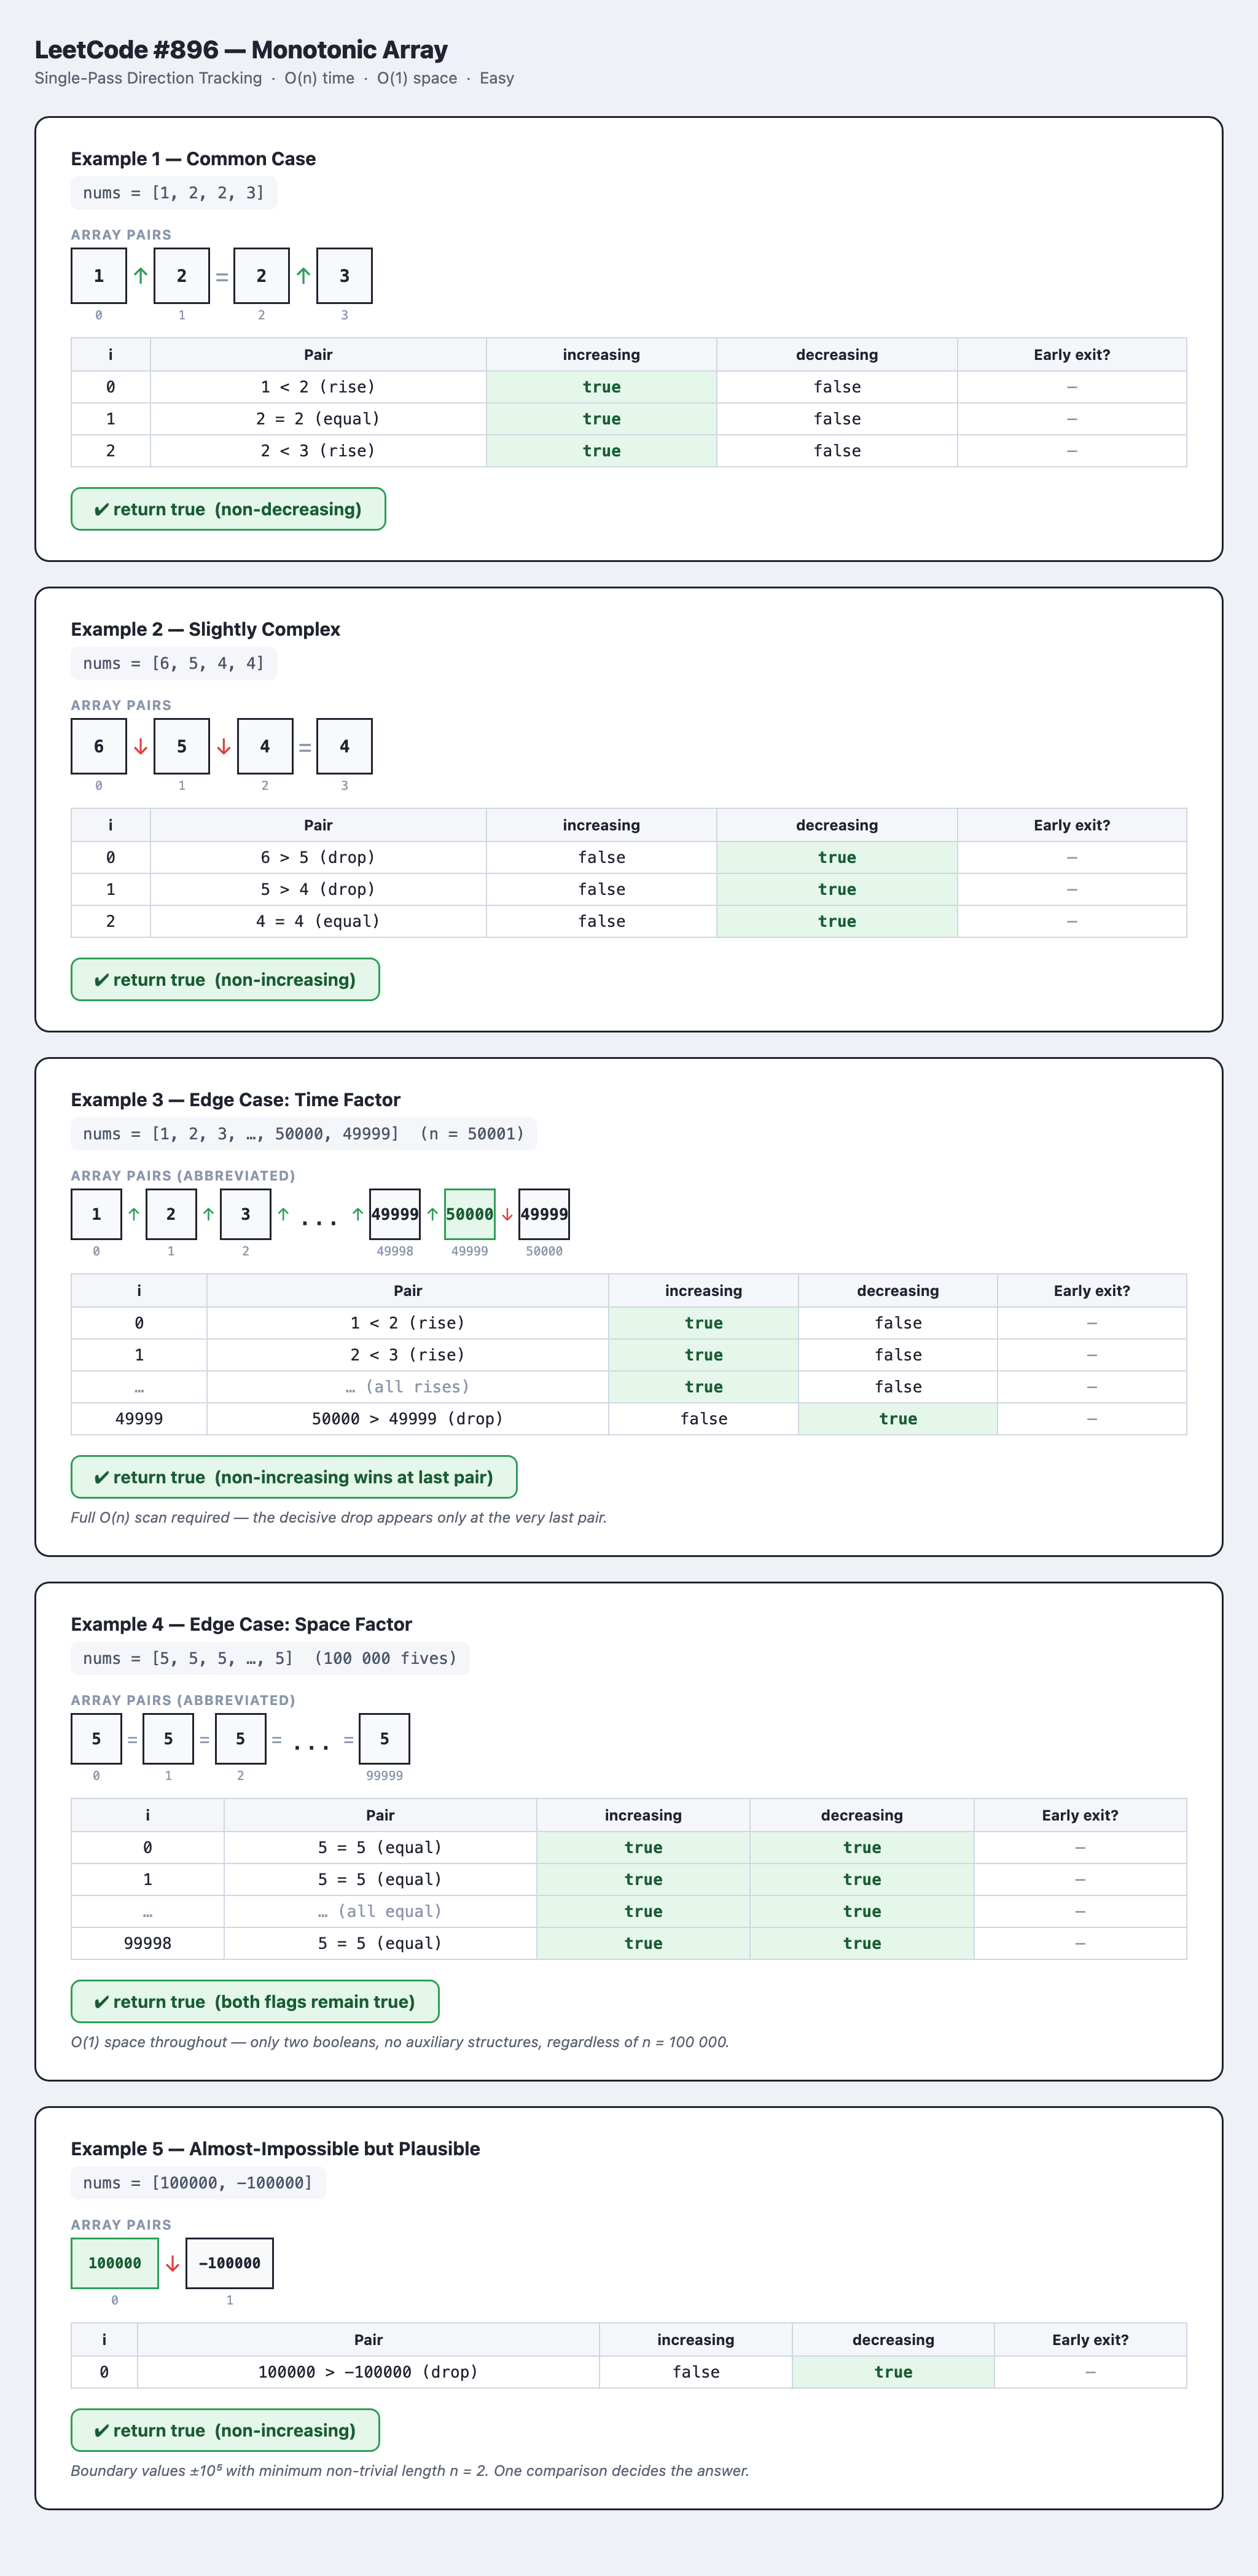